In [1]:
# IT's very important to compare you current portfolio vs a benchmark to understand if in the short 
# term you asset allocation i coherent with your risk profile. In this program the main benchmark 
# is considered 100%  MSCI WORLD.
#The idea is not to create a backtest in long period but to check if in the short period 
#your asset allocation can beat the benchmark in terms of risk adj return.
#So change free start and end date freely based on your need. 
#For the portfolio creation i used the most common asset tracker in a european portfolio: 
# S&P500, MSCI Europe, Asian stocks, European governament Bond, Gold. 
# change the weights, tickers, tickers description to adapt at your situations.


In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
start_date='2025-01-01'
end_date='2025-12-31'
MSCI_WORLD_Data= yf.download('SWDA.MI', start_date, end_date)['Close'].dropna()
MSCI_WORLD_Data=MSCI_WORLD_Data.rename(columns = {"SWDA.MI": "MSCI_WORLD"})
my_tickers = ["VUAA.MI", "SMEA.MI", "CSEMAS.MI", "SGLD.MI", "VGEA.MI","XDEV.MI"]
portfolio_prices=yf.download(my_tickers,start_date, end_date)['Close'].dropna()
portfolio_prices = portfolio_prices.rename(columns=
{ "VUAA.MI": "USA",
 "SMEA.MI": "EUROPE",
 "CSEMAS.MI": "ASIA",
 "SGLD.MI": "GOLD", 
 "VGEA.MI": "BONDS",
 "XDEV.MI":"VALUE"})

weights = {
 "USA": 0.30,
 "EUROPE": 0.25,
 "ASIA": 0.15,
 "GOLD": 0.10,
 "BONDS": 0.12,
 "VALUE":0.08}


      

/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1576/3458534081.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  MSCI_WORLD_Data= yf.download('SWDA.MI', start_date, end_date)['Close'].dropna()
[*********************100%***********************]  1 of 1 completed
/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1576/3458534081.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_prices=yf.download(my_tickers,start_date, end_date)['Close'].dropna()
[*********************100%***********************]  6 of 6 completed


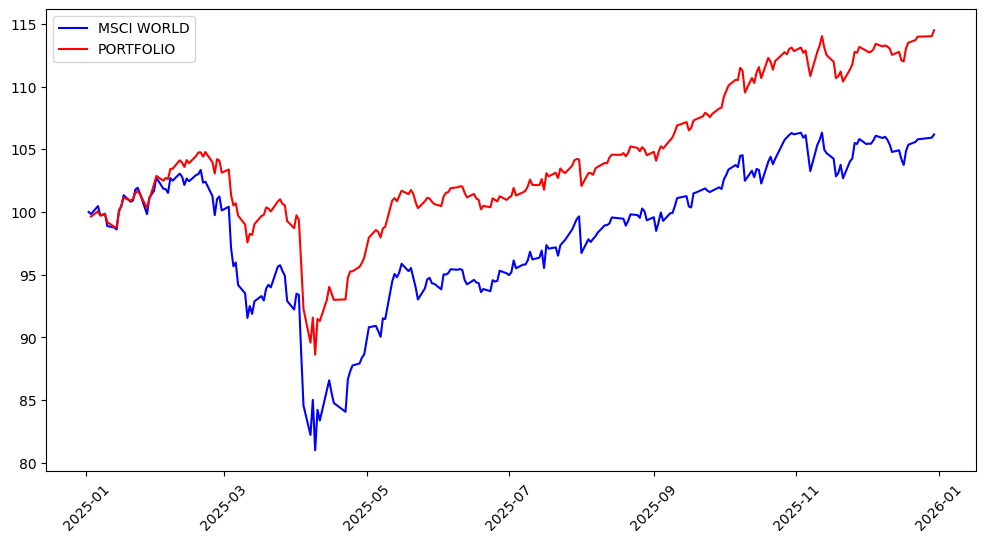

In [4]:
# After we download and organize the data let's normalize the price series and than plotted.
MSCI_WORLD_NORM= MSCI_WORLD_Data*100/(MSCI_WORLD_Data.iloc[0])
returns = portfolio_prices.pct_change().dropna()
portfolio_returns = (returns * weights).sum(axis=1)
PORTFOLIO_NORM = (1 + portfolio_returns).cumprod() * 100
plt.figure(figsize=(12,6))
plt.xticks(rotation=45)
plt.plot(MSCI_WORLD_NORM, label="MSCI WORLD",color='blue')
plt.plot(PORTFOLIO_NORM, label="PORTFOLIO",color='red')
plt.legend()
plt.show()


In [5]:
#now I proceed with the calculation of basic statistics. IN this short time they are not significative 
#stand alone but we can compare this asset allocation between each others. 
MSCI_WORLD_returns= MSCI_WORLD_Data.pct_change()
n_years= (pd.to_datetime(end_date)-pd.to_datetime(start_date)).days/365
MSCI_WORLD_annualreturn=(((MSCI_WORLD_Data.iloc[-1]/MSCI_WORLD_Data.iloc[0])**(1/n_years))-1)*100
PORTFOLIO_annualreturn=((PORTFOLIO_NORM.iloc[-1] / PORTFOLIO_NORM.iloc[0])**(1/n_years) - 1)*100
MSCI_WORLD_volatility=MSCI_WORLD_returns.std()*np.sqrt(252)*100
PORTFOLIO_volatility=portfolio_returns.std()*np.sqrt(252)*100
risk_free=0.015
MSCI_WORLD_sharpe=((MSCI_WORLD_annualreturn/100)-risk_free)/(MSCI_WORLD_volatility/100)
PORTFOLIO_sharpe=((PORTFOLIO_annualreturn/100)-risk_free)/(PORTFOLIO_volatility/100)

dictionary= {
    "Return (%)": [PORTFOLIO_annualreturn,MSCI_WORLD_annualreturn.iloc[0]],
    "Volatility (%)": [PORTFOLIO_volatility,MSCI_WORLD_volatility.iloc[0]],
    "Sharpe": [PORTFOLIO_sharpe, MSCI_WORLD_sharpe.iloc[0]]
}

index = ["PORTFOLIO", "MSCI WORLD"]

df = pd.DataFrame(dictionary, index=index)
df = df.round(2)
print(df)

            Return (%)  Volatility (%)  Sharpe
PORTFOLIO        14.96           12.21    1.10
MSCI WORLD        6.20           16.90    0.28
